# Circular Convolution and the Need for Zero Padding
This notebook demonstrates the need for zero padding in transient ISE problems that use frequency domain deconvolution. It is typical to adjust the frequency resolution of the FRFs to match the duration of the time domain responses either by interpolation in the frequency domain or zero padding the impulse response functions (IRFs). It is also common for the responses to be zero padded to mitigate circular convolution errors. Consequently, this notebook will demonstrate two scenarios:

1. A "minimum" zero padding scenario where the responses are not zero padded
2. A scenario with extra zero padding to mitigate the circular convolution errors that are seen in the first scenario

## Importing the Beam Model Information
This example uses the nominal beam system with the low frequency pulses. 

In [1]:
import sdynpy as sdpy
import numpy as np
from scipy.fft import irfft
from forcefinder.core.transient_utilities import sinc_interpolation
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':10,
                     'font.family':'Times New Roman'})

In [2]:
truth_pulse = sdpy.TimeHistoryArray.load(r'system_data/low_freq_truth_pulse_excitation.npz')
truth_response = sdpy.TimeHistoryArray.load(r'system_data/low_freq_truth_response.npz')
nominal_beam_system = sdpy.System.load(r'system_data/nominal_beam_system.npz')

## Computing the FRFs
The FRFs are computed using the `frequency_response` method in SDynPy, which uses the typical formulation with the mass, stiffness, and damping matrices from the `System` object. The FRFs were computed with an extremely high sample frequency to approximate a causal system, which will be [discussed in more detail later](noncausal_frfs.ipynb). They are also computed with a frequency resolution of 1 Hz, which is less than the responses. The frequency resolution was chosen to ensure that the frequency resolution of the FRFs needed to be adjusted for the transient ISE problem.

In [3]:
Fs = 10000 #Hz
T = 1 # seconds
frequency = np.arange(stop=Fs/2+1/T, step=1/T)

In [4]:
response_coordinate = sdpy.coordinate_array(node=[102,104,106,108], direction=3)
reference_coordinate = sdpy.coordinate_array(string_array=['103Z+', '104Z+'])

oversampled_frfs = nominal_beam_system.frequency_response(frequency, responses=response_coordinate, 
                                                  references=reference_coordinate, displacement_derivative=2)

The plot below shows the condition number of the FRF matrix, to provide context for the inverse problem. Note that there are no modes past 1,000 hz, so all the high frequency content is the tails of the system modes. 

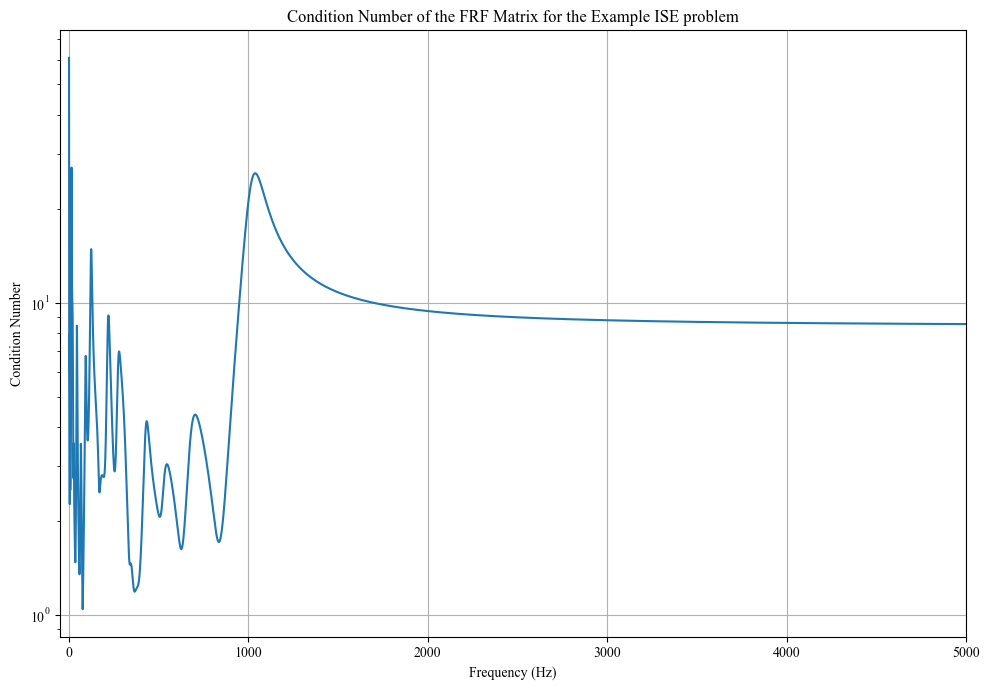

In [5]:
plt.figure(figsize=(10,7))
plt.semilogy(oversampled_frfs[0,0].abscissa, np.linalg.cond(np.moveaxis(oversampled_frfs.ordinate,-1,0)))
plt.xlabel('Frequency (Hz)'); plt.ylabel('Condition Number'); plt.grid();plt.xlim(left=-50,right=5000)
plt.title('Condition Number of the FRF Matrix for the Example ISE problem')
plt.tight_layout()

## ISE with Minimal Zero Padding
The responses are converted to the frequency domain using the `fft` method in SDynPy, where the normalization is set to 'backward'. The frequency resolution of the FRFs is adjusted to match the frequency resolution of the responses using the `sinc_interpolation` function from ForceFinder. This function converts the FRFs to IRFs (via an inverse DFT), zero pads the IRFs, then converts the IRFs back to FRFs (via a DFT). The implications of using this method over interpolation in the frequency domain will be demonstrated in the [notebook for zero padding](zero_padding.ipynb). 

In [6]:
truth_response_fft = truth_response.fft(norm='backward')
truth_response_fft_ord = np.moveaxis(truth_response_fft.ordinate,-1,0)[...,np.newaxis]

In [7]:
frfs_match_response_length = sinc_interpolation(np.moveaxis(oversampled_frfs.ordinate,-1,0), 
                                                truth_response.num_elements)

The forces are estimated in the frequency domain using the standard pseudo-inverse method, then converted back to the time domain using an inverse DFT with the SciPy `irfft` function. Note that the normalization in the inverse DFT is set to be the same as the as the normalization in the DFT that was used to convert the responses in the time domain. 

In [8]:
estimated_pulse_fft_no_padding = np.linalg.pinv(frfs_match_response_length)@truth_response_fft_ord
estimated_pulse_no_padding = irfft(estimated_pulse_fft_no_padding, n=truth_response.num_elements, 
                                   axis=0, norm='backward')

The estimated forces are shown in the plot below, which shows that the pulse is estimated with good accuracy but that there are several other "wiggles" in the time trace. The extra content in the early time, which is highlighted grey in the plot, is due to circular convolution error. 

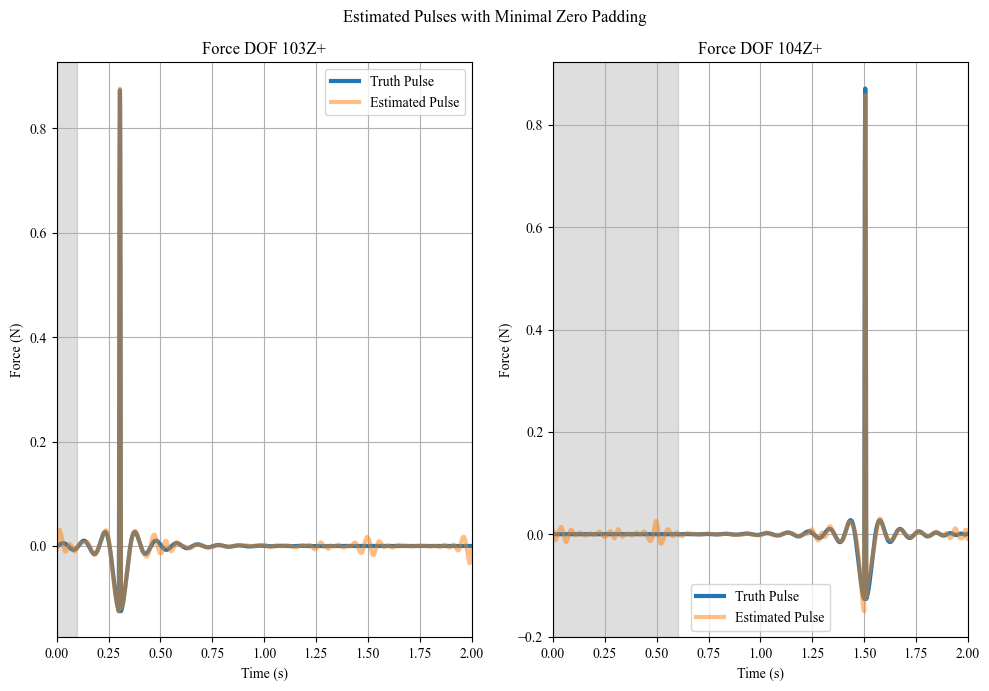

In [10]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

for ii in range(2):
    ax[ii].plot(truth_pulse[ii].abscissa, truth_pulse[ii].ordinate, 
                label='Truth Pulse', linewidth=3)
    ax[ii].plot(truth_pulse[ii].abscissa, estimated_pulse_no_padding[:,ii,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
    ax[ii].set_xlim(left=0, right=2)
    ax[ii].grid(); ax[ii].set_xlabel('Time (s)'); ax[ii].set_ylabel('Force (N)') 
    ax[ii].set_title('Force DOF {:}'.format(truth_pulse[ii].response_coordinate.string_array()));
    ax[ii].legend(); 

ax[0].axvspan(xmin=0, xmax=0.1, alpha=0.25, color='tab:grey', zorder=0)
ax[1].axvspan(xmin=0, xmax=0.6, alpha=0.25, color='tab:grey', zorder=0)

fig.suptitle('Estimated Pulses with Minimal Zero Padding')
fig.tight_layout()

## Zero Padding to Mitigate Circular Convolution Errors
As previously mentioned, the classical method for mitigating circular convolution error is to zero pad the response data. In this case the responses are zero padded before and after the response time range with the `zero_pad` method in SDynPy. The number of zeros in this function is set to be two times the `model_order`, which is the number of samples in the IRFs that are computed from the unadjusted FRFs. In the `zero_pad` function, the number of zeros is evenly split between the time range before and after the actual response time duration when `left` and `right` keyword arguments are set to `True` (which is the case here). 

In [11]:
model_order = oversampled_frfs.ifft().num_elements
padded_response = truth_response.zero_pad(2*model_order, left=True, right = True,
                                          use_next_fast_len=False)
padded_response_fft = padded_response.fft(norm='backward')
padded_response_fft_ord = np.moveaxis(padded_response_fft.ordinate,-1,0)[...,np.newaxis]

The frequency resolution of the FRFs is adjusted using the same `sinc_interpolation` function as the minimal zero padding scenario.

In [12]:
frfs_zero_padded = sinc_interpolation(np.moveaxis(oversampled_frfs.ordinate,-1,0), 
                                                padded_response.num_elements)

The forces are estimated using the standard pseudo-inverse method. 

In [13]:
estimated_pulse_fft_padded = np.linalg.pinv(frfs_zero_padded)@padded_response_fft_ord
estimated_pulse_padded = irfft(estimated_pulse_fft_padded, n=padded_response.num_elements, 
                                   axis=0, norm='backward')

The plot below shows how the extra zero padding mitigates the extra content in the pulse time trace that was due to the circular convolution errors. The grey highlighted regions are the same as plots from above so the same time ranges can be easily compared. 

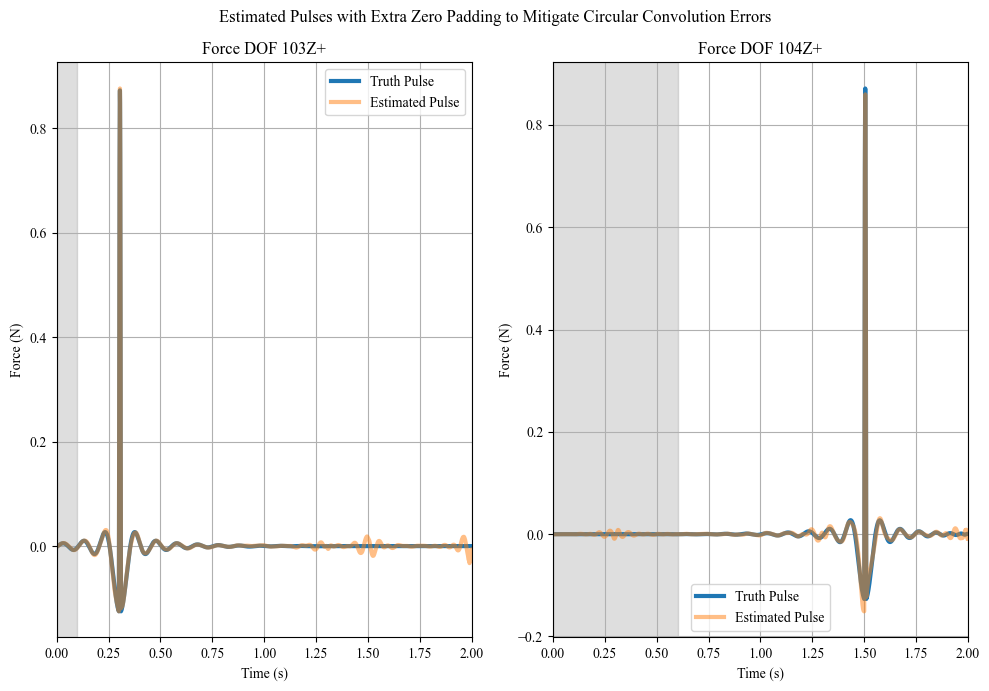

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,7))

for ii in range(2):
    ax[ii].plot(truth_pulse[ii].abscissa, truth_pulse[ii].ordinate, 
                label='Truth Pulse', linewidth=3)
    ax[ii].plot(padded_response[ii].abscissa, estimated_pulse_padded[:,ii,:], 
                label='Estimated Pulse', linewidth=3, alpha=0.5)
    ax[ii].set_xlim(left=0, right=2)
    ax[ii].grid(); ax[ii].set_xlabel('Time (s)'); ax[ii].set_ylabel('Force (N)') 
    ax[ii].set_title('Force DOF {:}'.format(truth_pulse[ii].response_coordinate.string_array()));
    ax[ii].legend(); 

ax[0].axvspan(xmin=0, xmax=0.1, alpha=0.25, color='tab:grey', zorder=0)
ax[1].axvspan(xmin=0, xmax=0.6, alpha=0.25, color='tab:grey', zorder=0)

fig.suptitle('Estimated Pulses with Extra Zero Padding to Mitigate Circular Convolution Errors')
fig.tight_layout()